In [9]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models
from keras.models import Sequential, Model
from loss import custom_loss
from keras.losses import MeanSquaredError
from keras.layers import *
from keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose
from qkeras import *

import importlib



In [10]:
from OptimizedDataGenerator_v2 import OptimizedDataGenerator as NewDG
from loss import *
import models
importlib.reload(models)
from models import var_network
from models import CreateModel

from SoftQuantizeLayer import SoftQuantizeLayer
from AnnealingScheduler import AnnealingScheduler
# from models.models import CreateModel # Conv2D model

from dataset_utils import add_noise

import matplotlib.pyplot as plt
pi = 3.14159265359

maxval=1e9
minval=1e-9

In [11]:
'''Load data for regression training'''

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = os.path.join(dataset_base_dir, "tfrecords")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train",'3sr_16x16_80eN_raw')
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_80eN_raw')


validation_generator = NewDG(
    load_from_tfrecords_dir = tfrecords_dir_val,
)
training_generator = NewDG(
    load_from_tfrecords_dir = tfrecords_dir_train,
)



Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_80eN_raw/metadata.json


Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_train/3sr_16x16_80eN_raw/metadata.json


In [12]:
def var_network(var, hidden=10, output=2):
    var = Flatten()(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    var = QDense(
        hidden,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(8, 0, 1)")(var)
    return QDense(
        output,
        kernel_quantizer=quantized_bits(8, 0, alpha=1),
        bias_quantizer=quantized_bits(8, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
    )(var)

def conv_network(var, n_filters=5, kernel_size=3):
    var = QSeparableConv2D(
        n_filters,kernel_size,
        depthwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        pointwise_quantizer=quantized_bits(4, 0, 1, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        depthwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        pointwise_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)
    var = QConv2D(
        n_filters,1,
        kernel_quantizer=quantized_bits(4, 0, alpha=1),
        bias_quantizer=quantized_bits(4, 0, alpha=1),
        kernel_regularizer=tf.keras.regularizers.L1L2(0.01),
        activity_regularizer=tf.keras.regularizers.L2(0.01),
    )(var)
    var = QActivation("quantized_tanh(4, 0, 1)")(var)    
    return var

def CreateModel(shape, output, n_filters, pool_size):
    x_base = x_in = Input(shape)
    x_base = SoftQuantizeLayer(
        n_bits=2,
        initial_thresholds = [247.80, 668.41, 1662.85],
        # initial_levels = [0.0, 0.33333, 0.66667, 1.0],
        initial_levels = [0.0, 1.0, 2.0, 3.0],
        threshold_offset = 80.0,
        # initial_range=[-1.0, 1.0],
        trainable_levels=False,
        trainable_thresholds=True,
        initial_k=1.0,
        trainable_k=True,
        name='soft_quantizer_output'
    )(x_base)
    stack = conv_network(x_base)
    stack = AveragePooling2D(
        pool_size=(pool_size, pool_size), 
        strides=None, 
        padding="valid", 
        data_format=None,        
    )(stack)
    stack = QActivation("quantized_bits(8, 0, alpha=1)")(stack)
    stack = var_network(stack, hidden=16, output=output)
    model = Model(inputs=x_in, outputs=stack)
    return model

In [13]:
weights_path = './trained_models/model-78aafdb8-2March26_test-checkpoints/'
base_dir = weights_path
checkpoint_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.hdf5')]
latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
#training_cp_path = os.path.join(base_dir, 'training_log.csv')
#training_history = pd.read_csv(training_cp_path)

print(f"Loading model from {latest_checkpoint}")

model=CreateModel(shape = (16,16,2), output = 14, n_filters=5,pool_size=3)
model.summary()
model.load_weights(latest_checkpoint)



Loading model from ./trained_models/model-78aafdb8-2March26_test-checkpoints/weights.814-t-21485.0449-v-22776.8984.hdf5


2026-03-03 18:50:54.783064: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-03 18:50:54.857605: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-03 18:50:54.858094: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-03 18:50:54.859037: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16, 16, 2)]       0         
                                                                 
 soft_quantizer_output (Soft  (None, 16, 16, 2)        4         
 QuantizeLayer)                                                  
                                                                 
 q_separable_conv2d (QSepara  (None, 14, 14, 5)        33        
 bleConv2D)                                                      
                                                                 
 q_activation (QActivation)  (None, 14, 14, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 14, 14, 5)         30        
                                                                 
 q_activation_1 (QActivation  (None, 14, 14, 5)        0     

Index(['epoch', 'k', 'level_0', 'level_1', 'level_2', 'level_3', 'threshold_0',
       'threshold_1', 'threshold_2', 'raw_first_level',
       'raw_log_level_delta_0', 'raw_log_level_delta_1',
       'raw_log_level_delta_2', 'raw_first_threshold'],
      dtype='object')


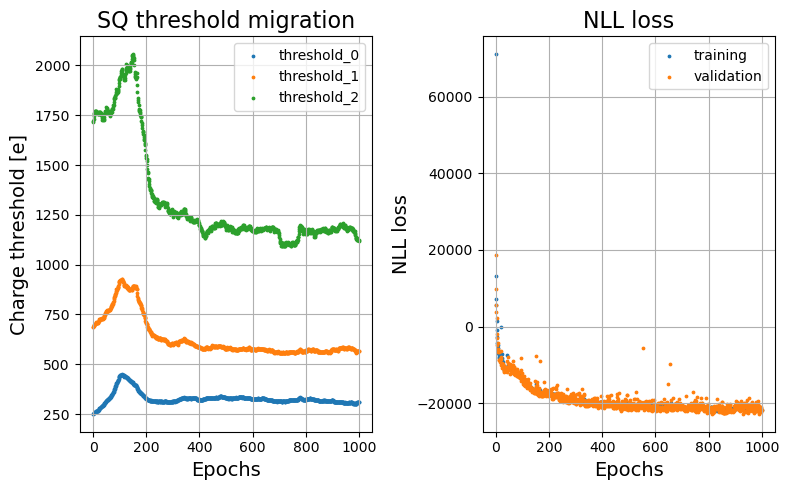

In [14]:
'''Threshold migration and loss optimization for one training'''
SQ_log = pd.read_csv(os.path.join(weights_path, 'soft_quantizer_state_log.csv'))
print(SQ_log.columns)

th_keys = [f'threshold_{i}' for i in range(3)]

fig, ax = plt.subplots(1,2, figsize = (8,5))
for i, th_key in enumerate(th_keys):
    epochs = SQ_log['epoch']
    th_charge = SQ_log[th_key]
    ax[0].scatter(epochs, th_charge, s=3)

ax[0].grid()
ax[0].legend(th_keys)
ax[0].set_xlabel('Epochs', fontsize =14)
ax[0].set_ylabel('Charge threshold [e]', fontsize = 14)
ax[0].set_title('SQ threshold migration', fontsize = 16)


# checkpoint_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.hdf5')]
# latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
training_cp_path = os.path.join(weights_path, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

ax[1].scatter(training_history['epoch'], training_history['loss'], s=3)
ax[1].scatter(training_history['epoch'], training_history['val_loss'], s=3)
ax[1].legend(['training', 'validation'])
ax[1].grid(True)
ax[1].set_xlabel('Epochs', fontsize = 14)
ax[1].set_title('NLL loss', fontsize = 16)
ax[1].set_ylabel('NLL loss', fontsize = 14)

fig.tight_layout()


    

In [15]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def pull_plot(ax, var, name, label, p=0):
    
    h = ax.hist(df[var],bins=np.linspace(-5,5,50),histtype='step', label=label)
    ax.set_xlabel(name)
    ax.set_yscale('log')

    ydata = h[0]
    xdata = h[1][:-1]+3/50.

    pars, cov = curve_fit(gauss,xdata,ydata)

    xbins = np.linspace(-5,5,100)
    ax.plot(xbins,gauss(xbins,pars[0],pars[1],pars[2]),color='black')
    ax.set_ylim(0.5,100000)

    print('Mean',pars[1])
    print('Sigma',pars[2])

    if p:
        ax.text(-1,25,"$\mu$="+str(round(pars[1],2)))
        ax.text(-1,10,"$\sigma$="+str(round(abs(pars[2]),2)))

def residual_plot(ax, thisdf, var1, var2, name, label, scaling=1.0,color = 'blue'):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color = color)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = residual_scaled
    # print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2, color = color)
    print(f"{name} spread: ",np.mean(np.array(upbar)-np.array(downbar)))
    
def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, label, scaling=1.0, color = 'blue'):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, label=label, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax, label=label, color = color)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    # print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2, color = color)
    print(f"{name} spread: ",np.mean(np.array(upbar)-np.array(downbar)))

Loading model from ./trained_models/model-78aafdb8-2March26_test-checkpoints/weights.814-t-21485.0449-v-22776.8984.hdf5
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16, 16, 2)]       0         
                                                                 
 soft_quantizer_output (Soft  (None, 16, 16, 2)        4         
 QuantizeLayer)                                                  
                                                                 
 q_separable_conv2d (QSepara  (None, 14, 14, 5)        33        
 bleConv2D)                                                      
                                                                 
 q_activation (QActivation)  (None, 14, 14, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 14, 14, 5)         30        
       

 4/21 [====>.........................] - ETA: 0s

2026-03-03 18:53:01.755750: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-03-03 18:53:01.767033: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8800


21/21 [==============================] - 2s 65ms/step


100%|██████████| 21/21 [00:01<00:00, 18.42it/s]


SQ 80eNoise MaxConv2D
$x$ [um] spread:  20.415411
$y$ [um] spread:  4.4390154


/tmp/ipykernel_219927/3489528821.py:59: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


$\alpha$ [deg] spread:  30.61776


/tmp/ipykernel_219927/3489528821.py:59: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


$\beta$ [deg] spread:  8.551102


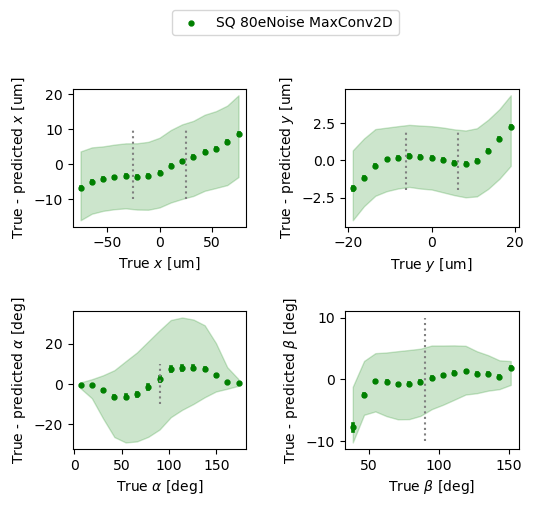

In [18]:
weights = [
            './trained_models/model-78aafdb8-2March26_test-checkpoints/'
          ]
tfrs = [
        'TFR_val/3sr_16x16_80eN_raw',
        ]

labels = [
          'SQ 80eNoise MaxConv2D'
          ]
colors = ['green', 'blue', 'red']

# p=[0,1]

nl = int(len(weights))

# fig, axes = plt.subplots(2,2,sharex=True,sharey=True,figsize=(6,5))
fig1, axes1 = plt.subplots(2,2,figsize=(6,5))
# fig1, axes1 = plt.subplots(1, 1, figsize=(5,4))
fig1.tight_layout(pad=4.0)

for i in range(nl):
    # base_dir = f'./weights-200ps_'+str(t0)
    base_dir = weights[i]
    checkpoint_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.hdf5')]
    latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    #training_cp_path = os.path.join(base_dir, 'training_log.csv')
    #training_history = pd.read_csv(training_cp_path)
    print(f"Loading model from {latest_checkpoint}")

    CreateModel(shape = (16,16,2), output = 14, n_filters=5,pool_size=3)

    model.load_weights(latest_checkpoint)
    model.summary()
    
    tfrecords_dir_val = "/uscms/home/bweiss/nobackup/smart-pixels/tfrecords/"+tfrs[i]
    test_generator = NewDG(
        load_from_tfrecords_dir = tfrecords_dir_val,
    )
    # print(test_generator[0][0][:,:,:])

    # predicts test data
    p_test = model.predict(test_generator)
    
    complete_truth = None
    for _, y in tqdm(test_generator):
            if complete_truth is None:
                complete_truth = y
            else:
                complete_truth = np.concatenate((complete_truth, y), axis=0)
    
    # creates df with all predicted values and matrix elements - 4 predictions, all 10 unique matrix elements
    df = pd.DataFrame(p_test,columns=['x','M11','y','M22','cotA','M33','cotB','M44','M21','M31','M32','M41','M42','M43'])

    # df['x'] = df['x']*75.0
    # df['y'] = df['y']*18.75
    
    # stores all true values in same matrix as xtrue, ytrue, etc.
    df['xtrue'] = complete_truth[:,0]
    df['ytrue'] = complete_truth[:,1]
    df['cotAtrue'] = complete_truth[:,2]
    df['cotBtrue'] = complete_truth[:,3]
    df['M11'] = minval+tf.math.maximum(df['M11'], 0)
    df['M22'] = minval+tf.math.maximum(df['M22'], 0)
    df['M33'] = minval+tf.math.maximum(df['M33'], 0)
    df['M44'] = minval+tf.math.maximum(df['M44'], 0)
    
    df['sigmax'] = abs(df['M11'])
    df['sigmay'] = np.sqrt(df['M21']**2 + df['M22']**2)
    df['sigmacotA'] = np.sqrt(df['M31']**2+df['M32']**2+df['M33']**2)
    df['sigmacotB'] = np.sqrt(df['M41']**2+df['M42']**2+df['M43']**2+df['M44']**2)
    
    # calculates residuals for x, y, cotA, cotB
    residuals = df['xtrue'] - df['x']
    residualsy = df['ytrue'] - df['y']
    residualsA = df['cotAtrue'] - df['cotA']
    residualsB = df['cotBtrue'] - df['cotB']
    
    df['pullx'] = (df['xtrue']-df['x'])/df['sigmax']
    df['pully'] = (df['ytrue']-df['y'])/df['sigmay']
    df['pullcotA'] = (df['cotAtrue']-df['cotA'])/df['sigmacotA']
    df['pullcotB'] = (df['cotBtrue']-df['cotB'])/df['sigmacotB']

    ### Residual Plots ###
    print(labels[i])
    residual_plot(axes1[0][0],df,'xtrue','x',r'$x$ [um]', labels[i], scaling=75.0, color = colors[i])
    axes1[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
    axes1[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
    residual_plot(axes1[0][1],df,'ytrue','y',r'$y$ [um]', labels[i], scaling=18.75, color = colors[i])
    axes1[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
    axes1[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
    residual_plot_deg(axes1[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', labels[i], scaling=8.0, color = colors[i])
    axes1[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
    residual_plot_deg(axes1[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', labels[i], scaling=1.7, color = colors[i])
    axes1[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')    
    save_fig_path = os.path.join(base_dir, 'summary1.png')
    
    # residual_plot_deg(axes1,df,'cotAtrue','cotA',r'$\alpha$ [deg]', labels[i], scaling=8.0)
    # axes1.plot([90,90],[-10,10],color='gray',linestyle=':')
# print("done!")
nl = int(len(weights))
lines_labels = [ax.get_legend_handles_labels() for ax in fig1.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lgd = fig1.legend(lines[:nl], labels[:nl], bbox_to_anchor=(0.5, 1.05), loc='upper center', ncol=2)
plt.savefig(save_fig_path, bbox_extra_artists=(lgd,), bbox_inches='tight')
